# 02 - Exploratory Data Analysis (EDA)
Analisis mendalam terhadap dataset GDP Growth Indonesia.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../data/eda_outputs', exist_ok=True)

df = pd.read_csv('../data/processed/dataset_indonesia.csv')
print('Shape:', df.shape)
df.head()

Shape: (34, 9)


,Year,GDP_Growth,Inflation,Unemployment,Population_Growth,Exports,Imports,FDI,Exchange_Rate
0,1991,6.911983,9.419068,2.617,1.770137,28.351261,26.488304,1.270772,1950.317500
1,1992,6.497507,7.523510,2.734,1.733226,30.307464,27.119971,1.387989,2029.920833
2,1993,6.496408,9.671911,2.782,1.701584,26.754813,23.768572,1.268301,2087.103867
3,1994,7.539971,8.531998,4.366,1.685952,26.511428,25.365673,1.192252,2160.753675
4,1995,8.220007,9.420303,4.611,1.662785,26.312165,27.646425,2.150080,2248.607975


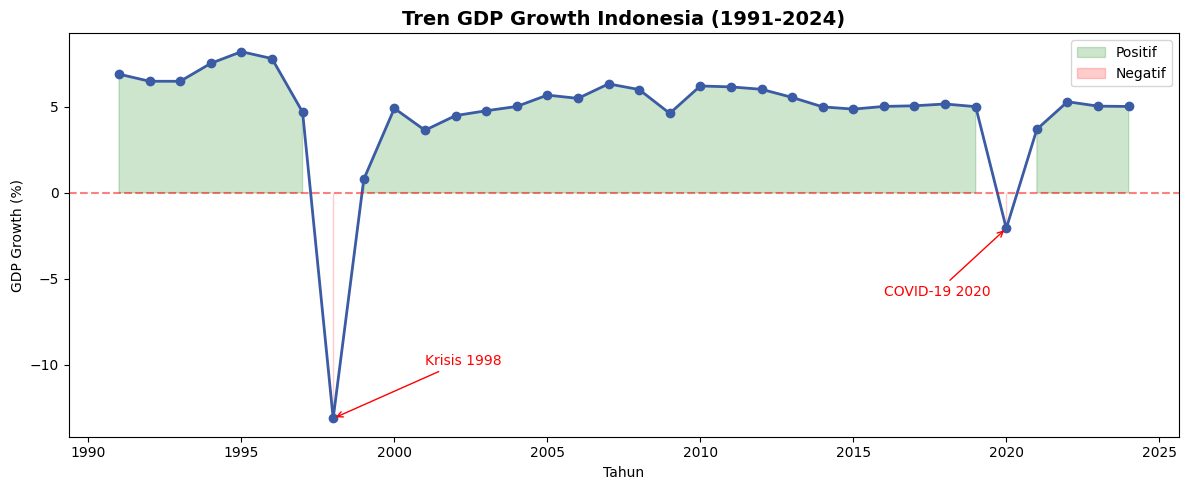

In [2]:
# 1. Tren GDP Growth
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['Year'], df['GDP_Growth'], marker='o', color='#3B5BA5', linewidth=2)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.fill_between(df['Year'], df['GDP_Growth'], 0,
                where=(df['GDP_Growth'] >= 0), alpha=0.2, color='green', label='Positif')
ax.fill_between(df['Year'], df['GDP_Growth'], 0,
                where=(df['GDP_Growth'] < 0), alpha=0.2, color='red', label='Negatif')
ax.set_title('Tren GDP Growth Indonesia (1991-2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tahun')
ax.set_ylabel('GDP Growth (%)')
ax.legend()
# Annotasi krisis
ax.annotate('Krisis 1998', xy=(1998, df.loc[df['Year']==1998,'GDP_Growth'].values[0]),
            xytext=(2001, -10), arrowprops=dict(arrowstyle='->', color='red'), color='red')
ax.annotate('COVID-19 2020', xy=(2020, df.loc[df['Year']==2020,'GDP_Growth'].values[0]),
            xytext=(2016, -6), arrowprops=dict(arrowstyle='->', color='red'), color='red')
plt.tight_layout()
plt.savefig('../data/eda_outputs/gdp_trend.png', dpi=150)
plt.show()

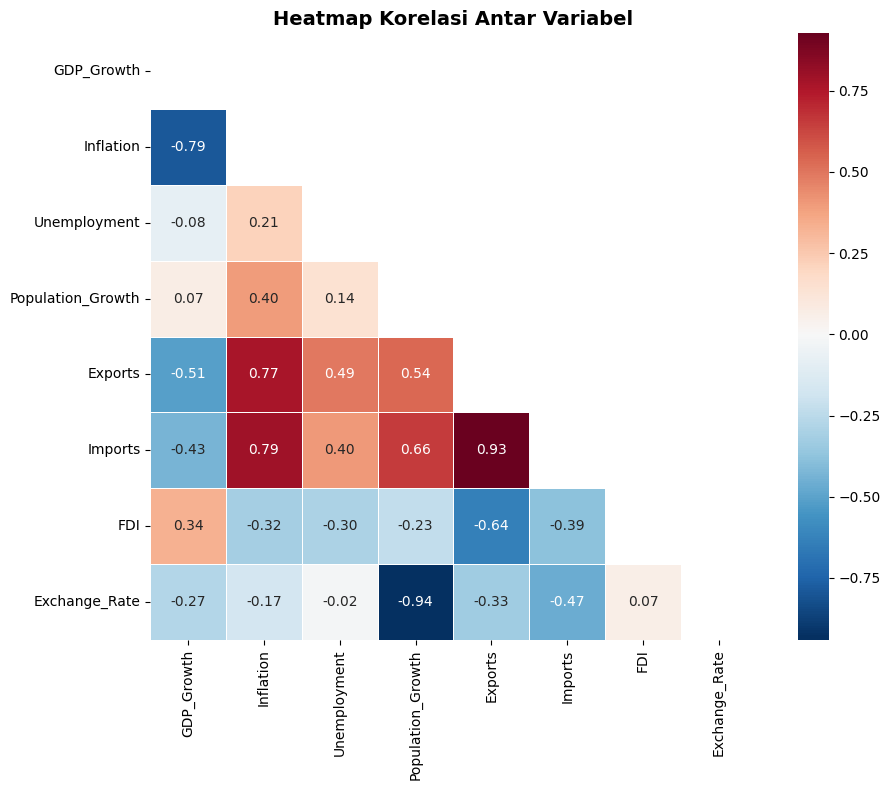

Korelasi dengan GDP_Growth:


FDI                  0.335765
Population_Growth    0.067148
Unemployment        -0.084696
Exchange_Rate       -0.271768
Imports             -0.430013
Exports             -0.510544
Inflation           -0.789140
Name: GDP_Growth, dtype: float64

In [3]:
# 2. Heatmap Korelasi
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.drop('Year', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Heatmap Korelasi Antar Variabel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_outputs/correlation_heatmap.png', dpi=150)
plt.show()
print('Korelasi dengan GDP_Growth:')
corr['GDP_Growth'].drop('GDP_Growth').sort_values(ascending=False)

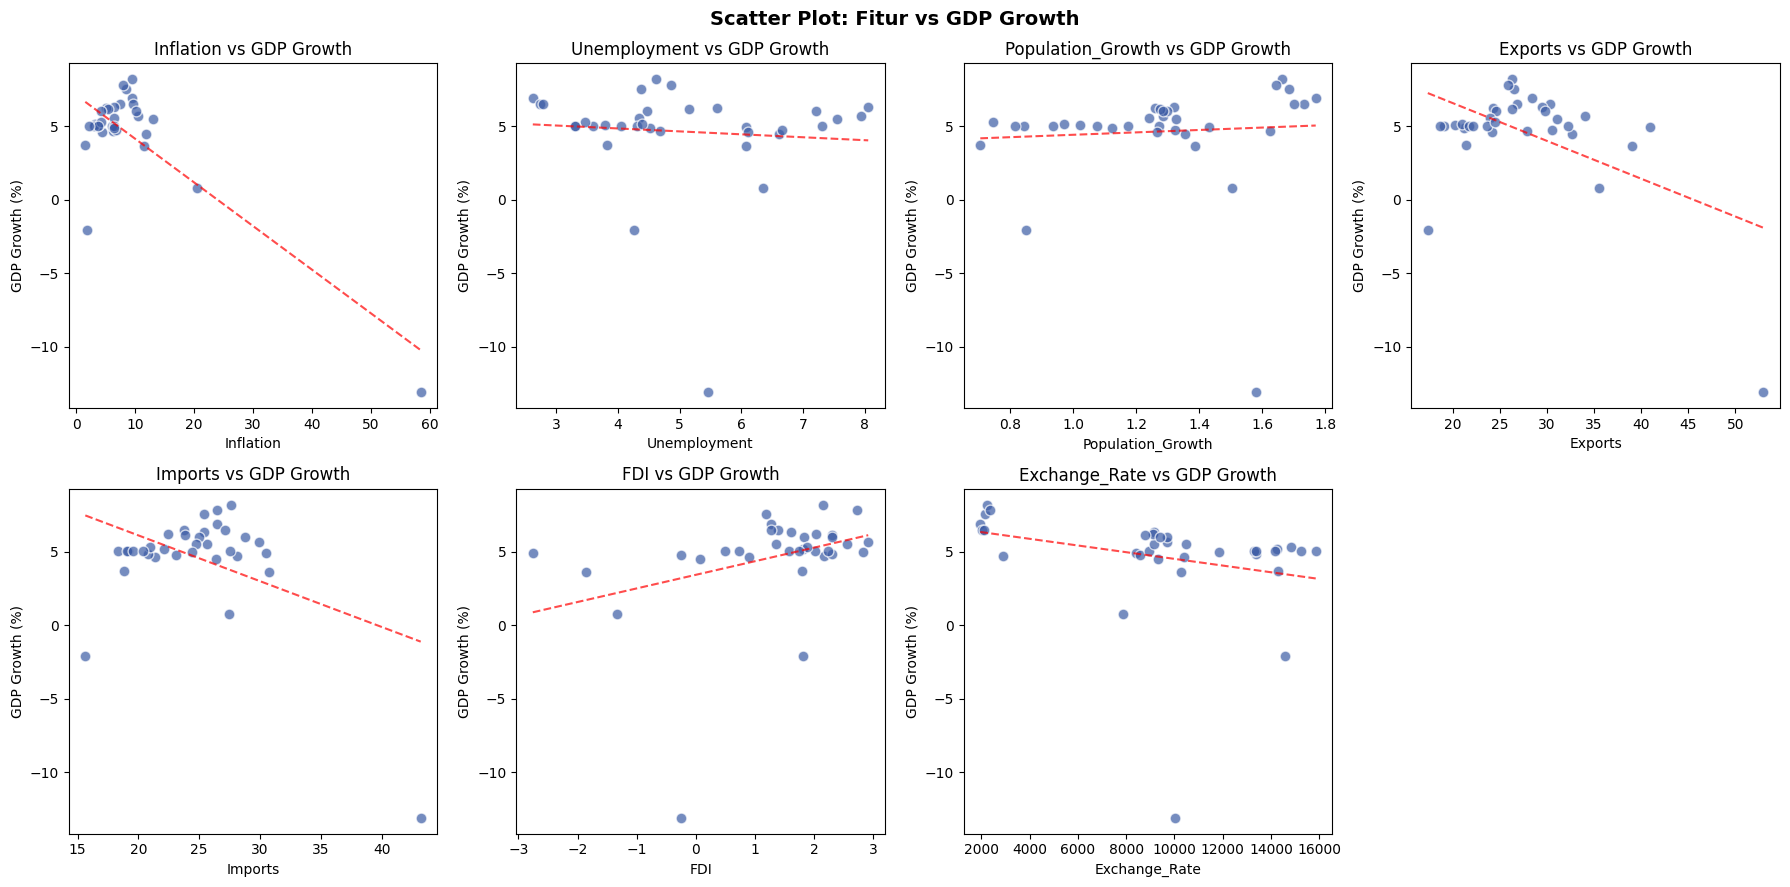

In [4]:
# 3. Scatter plots tiap variabel vs GDP Growth
features = ['Inflation', 'Unemployment', 'Population_Growth',
            'Exports', 'Imports', 'FDI', 'Exchange_Rate']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, feat in enumerate(features):
    axes[i].scatter(df[feat], df['GDP_Growth'], alpha=0.7, color='#3B5BA5', edgecolors='white', s=60)
    z = np.polyfit(df[feat].dropna(), df.loc[df[feat].notna(), 'GDP_Growth'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r--', alpha=0.7)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('GDP Growth (%)')
    axes[i].set_title(f'{feat} vs GDP Growth')
axes[-1].set_visible(False)
plt.suptitle('Scatter Plot: Fitur vs GDP Growth', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_outputs/scatter_plots.png', dpi=150)
plt.show()

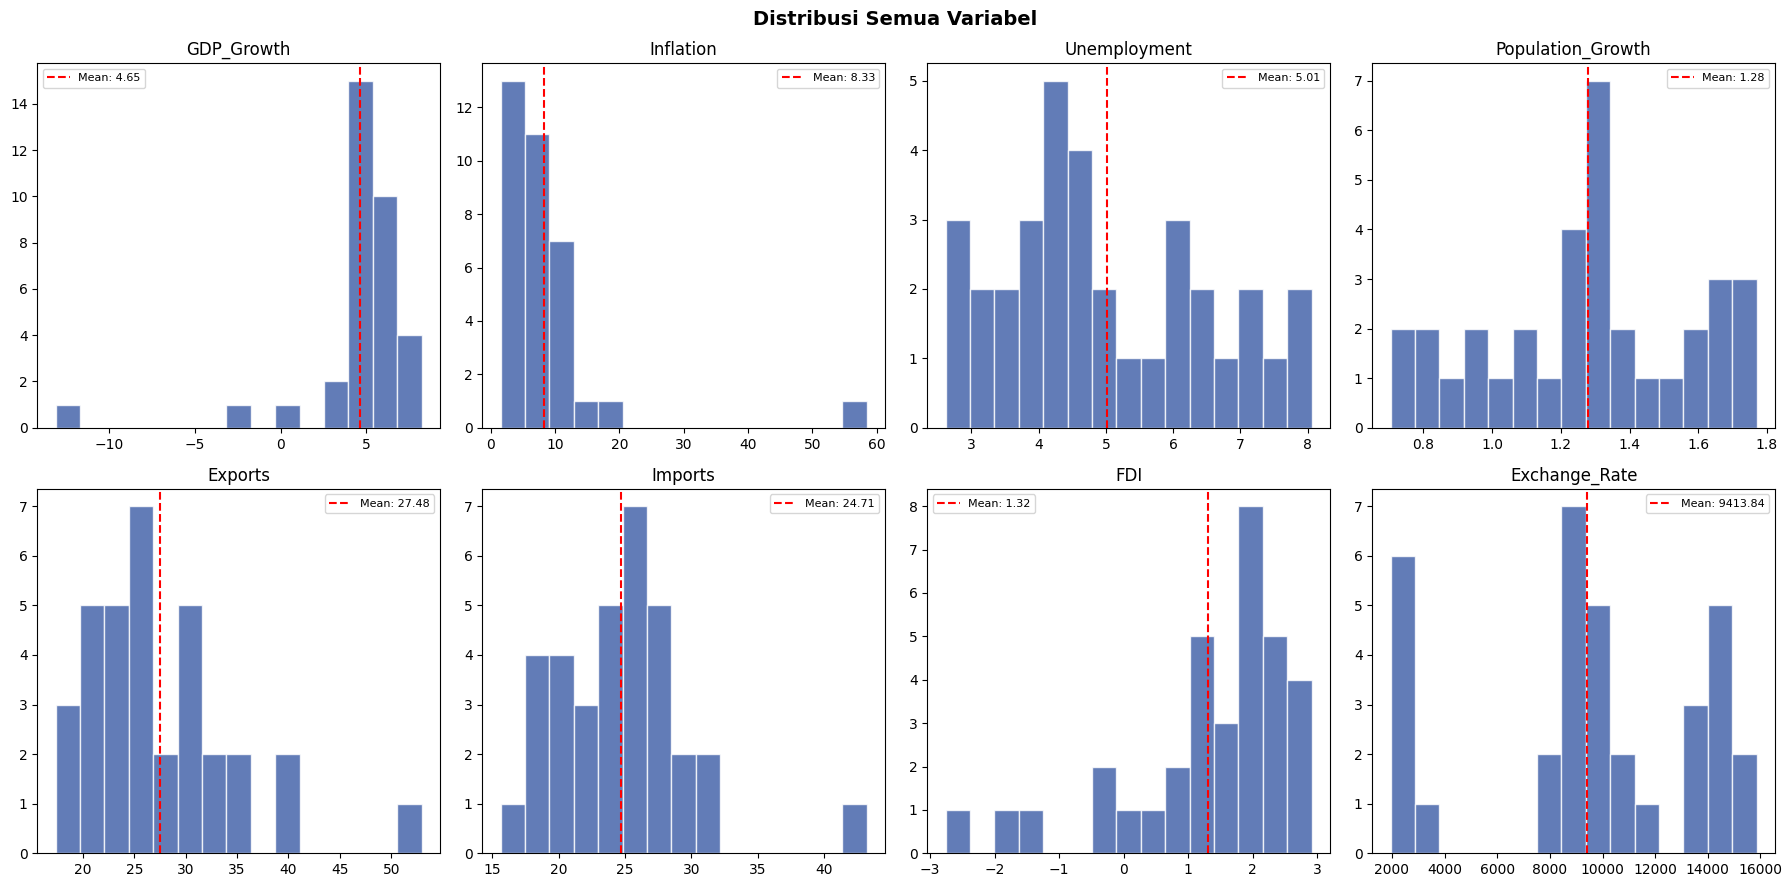

In [5]:
# 4. Distribusi semua variabel
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
all_cols = ['GDP_Growth'] + features
for i, col in enumerate(all_cols):
    axes[i].hist(df[col].dropna(), bins=15, color='#3B5BA5', edgecolor='white', alpha=0.8)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
plt.suptitle('Distribusi Semua Variabel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_outputs/distributions.png', dpi=150)
plt.show()

In [6]:
# 5. Statistik deskriptif lengkap
desc = df.describe().round(3)
desc.to_csv('../data/eda_outputs/descriptive_stats.csv')
desc

,Year,GDP_Growth,Inflation,Unemployment,Population_Growth,Exports,Imports,FDI,Exchange_Rate
count,34.000,34.000,34.000,34.000,34.000,34.000,34.000,34.000,34.000
mean,2007.500,4.650,8.330,5.012,1.279,27.480,24.708,1.317,9413.840
std,9.958,3.639,9.660,1.544,0.299,7.220,5.018,1.320,4343.159
min,1991.000,-13.127,1.560,2.617,0.705,17.331,15.641,-2.757,1950.318
25%,1999.250,4.804,3.909,3.883,1.086,22.554,21.060,0.976,8460.615
50%,2007.500,5.059,6.379,4.562,1.285,26.320,24.851,1.763,9542.796
75%,2015.750,6.135,9.420,6.100,1.485,30.435,27.352,2.163,13362.707
max,2024.000,8.220,58.451,8.060,1.770,52.968,43.218,2.916,15855.448
